In [120]:
import warnings
warnings.filterwarnings("ignore")
from yfinance import download
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import concat
from matplotlib.patches import Ellipse
import numpy as np

---

# **1.0**

*Dados*

In [121]:
# Parametros
interval = "1mo"
ticker_ativo = "KLBN4.SA"
ticker_indice = "^BVSP"
period = "max"
column = "Close"

In [122]:
tickers = [ticker_ativo, ticker_indice]
df_ativo, df_indice = [
    download(
        ticker, 
        interval=interval, 
        period=period, 
        progress=False,
        auto_adjust=False
        ).droplevel(1, axis=1)[[column]].rename(columns={column: ticker}) for ticker in tickers
    ]


In [123]:
# Contatenando das tabelas
df = concat([df_ativo, df_indice], axis=1)

# Removendo valores iniciais faltantes
df = df.dropna()

df

Price,KLBN4.SA,^BVSP
Date,,
2008-01-01,1.096309,59490.000000
2008-02-01,1.029702,63489.000000
2008-03-01,1.044104,60968.000000
2008-04-01,1.170117,67868.000000
2008-05-01,1.157515,72593.000000
...,...,...
2025-08-01,3.653465,141422.000000
2025-09-01,3.544554,146237.000000
2025-10-01,3.554455,149540.000000


# **2.0**

*Funções*

In [124]:
def regressao_linear(x, y):
    x = np.arange(x)
    y = y
    coef = np.polyfit(x, y, 1)
    return coef[0] * x + coef[1]

# **3.0**

*Adicionando funções e calculos*

In [125]:
# Normalização das séries
for ticker in tickers:
    df[f'{ticker}_norm'] = df[f'{ticker}'] / df[f'{ticker}'].iloc[0]

df.iloc[:, 2:].head(3)

Price,KLBN4.SA_norm,^BVSP_norm
Date,,
2008-01-01,1.000000,1.000000
2008-02-01,0.939244,1.067221
2008-03-01,0.952381,1.024845


In [126]:
# Retornos das séries
for ticker in tickers:
    df[f'{ticker}_ret'] = df[f'{ticker}'].pct_change(1)

df.iloc[:, 4:].tail(3)

Price,KLBN4.SA_ret,^BVSP_ret
Date,,
2025-10-01,0.002793,0.022587
2025-11-01,-0.008357,0.063742
2025-12-01,0.069579,0.014489


In [127]:
# Calcula o coeficiente de correlação de Pearson entre o ativo e o índice dentro da janela móvel de 21 períodos.
df['corr_ret'] = df[ticker_ativo].rolling(21).corr(df[ticker_indice])
df.iloc[:, 6:].tail(3)

Price,corr_ret
Date,
2025-10-01,-0.716910
2025-11-01,-0.722253
2025-12-01,-0.680869


In [128]:
# Desvio padrão
for ticker in tickers:
    df[f'{ticker}_ret_sd_21'] = df[f'{ticker}'].rolling(21).std()

df.iloc[:, 7:].tail(3)

Price,KLBN4.SA_ret_sd_21,^BVSP_ret_sd_21
Date,,
2025-10-01,0.340128,7873.768020
2025-11-01,0.355479,9883.187327
2025-12-01,0.334888,11596.453765


In [129]:
df.isnull().sum()

Price
KLBN4.SA               0
^BVSP                  0
KLBN4.SA_norm          0
^BVSP_norm             0
KLBN4.SA_ret           1
^BVSP_ret              1
corr_ret              20
KLBN4.SA_ret_sd_21    20
^BVSP_ret_sd_21       20
dtype: int64

In [130]:
# regressão linear
for ticker in tickers:
    df[f'{ticker}_regressao_linear_close'] = regressao_linear(x=len(df), y=df[ticker].values)
    df[f'{ticker}_diferenca_regressao_linear_e_close'] = df[ticker] - df[f'{ticker}_regressao_linear_close']


In [131]:
df

Price,KLBN4.SA,^BVSP,KLBN4.SA_norm,^BVSP_norm,KLBN4.SA_ret,^BVSP_ret,corr_ret,KLBN4.SA_ret_sd_21,^BVSP_ret_sd_21,KLBN4.SA_regressao_linear_close,KLBN4.SA_diferenca_regressao_linear_e_close,^BVSP_regressao_linear_close,^BVSP_diferenca_regressao_linear_e_close
Date,,,,,,,,,,,,,
2008-01-01,1.096309,59490.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.763256,0.333053,36155.060099,23334.939901
2008-02-01,1.029702,63489.000000,0.939244,1.067221,-0.060756,0.067221,NaN,NaN,NaN,0.780939,0.248763,36575.015086,26913.984914
2008-03-01,1.044104,60968.000000,0.952381,1.024845,0.013987,-0.039708,NaN,NaN,NaN,0.798622,0.245482,36994.970074,23973.029926
2008-04-01,1.170117,67868.000000,1.067324,1.140830,0.120690,0.113174,NaN,NaN,NaN,0.816304,0.353813,37414.925062,30453.074938
2008-05-01,1.157515,72593.000000,1.055829,1.220256,-0.010770,0.069620,NaN,NaN,NaN,0.833987,0.323528,37834.880050,34758.119950
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,3.653465,141422.000000,3.332514,2.377240,0.002717,0.062756,-0.614962,0.308424,5749.530389,4.494332,-0.840867,124765.562514,16656.437486
2025-09-01,3.544554,146237.000000,3.233171,2.458178,-0.029810,0.034047,-0.668641,0.326585,6723.338268,4.512015,-0.967461,125185.517502,21051.482498
2025-10-01,3.554455,149540.000000,3.242202,2.513700,0.002793,0.022587,-0.716910,0.340128,7873.768020,4.529697,-0.975242,125605.472490,23934.527510


In [132]:
df.dropna(inplace=True)

# **4.0**

*Preços normalizados, correlação de person dos retornos e do desvio padrão dos retornos* 

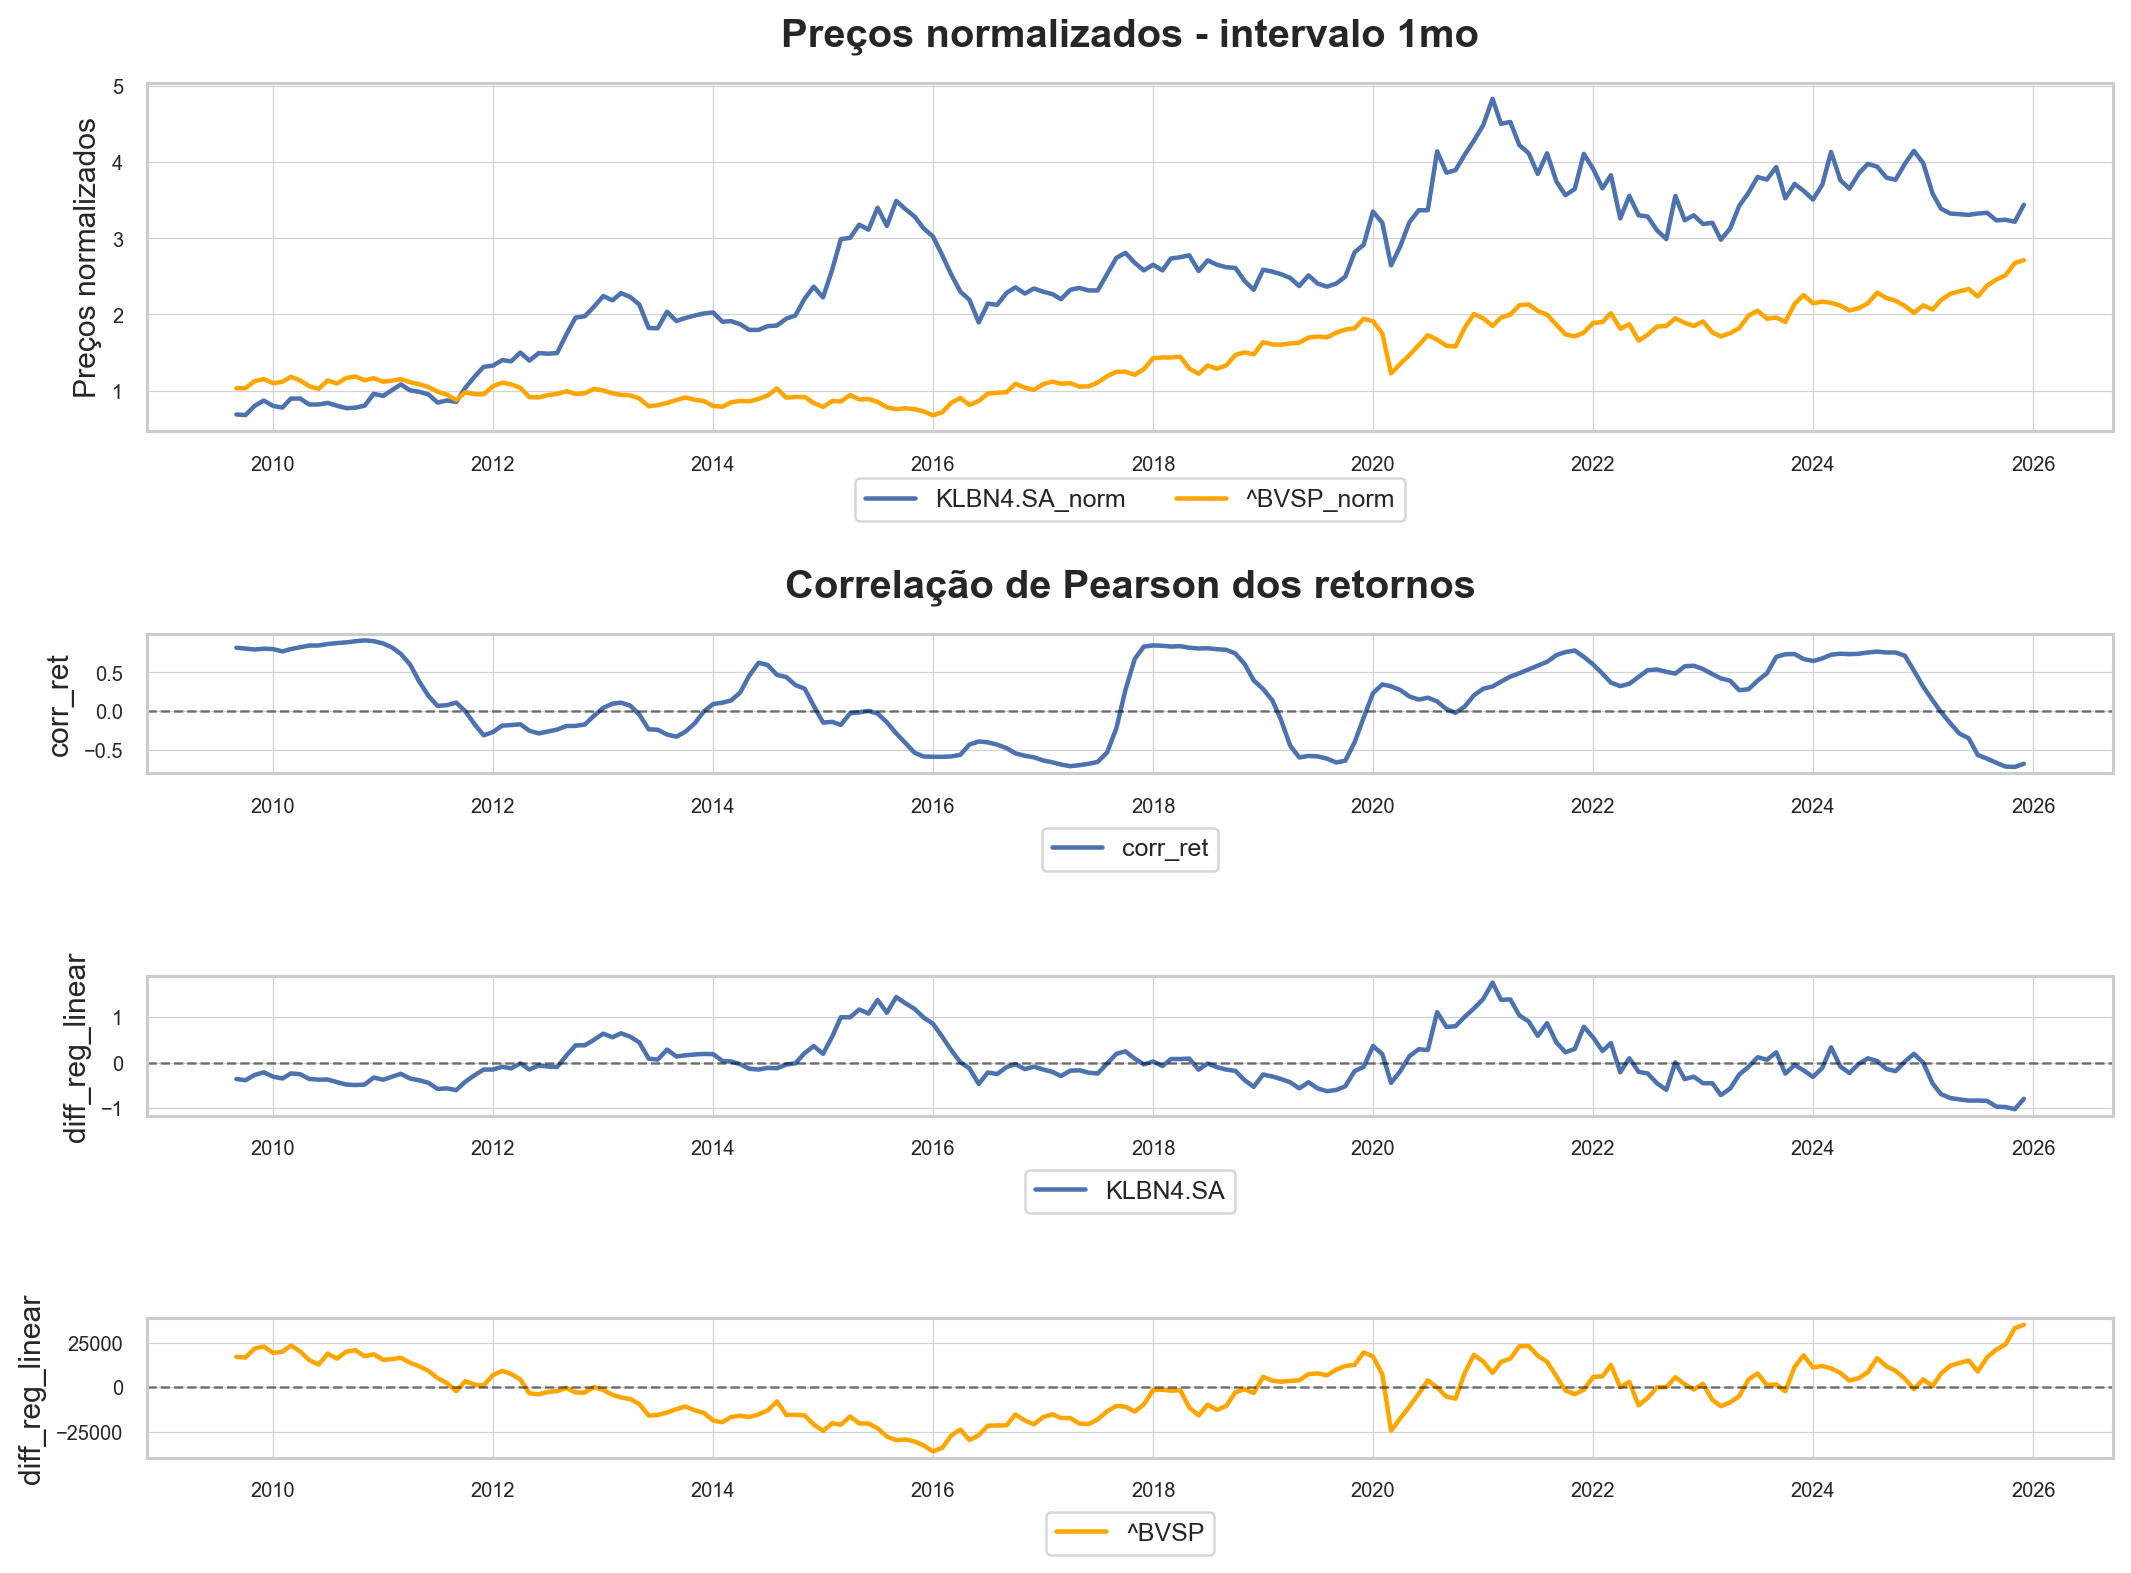

In [133]:
sns.set_theme(style="whitegrid")  
plt.rcParams["figure.dpi"] = 180

# Figura com quatro gráficos
fig, ax = plt.subplots(
    4, 1,
    figsize=(12, 9),
    sharex=False,
    sharey=False,
    gridspec_kw={"height_ratios": [3, 1.2, 1.2, 1.2]}
)

ax1 = ax[0]
ax2 = ax[1]
ax3 = ax[2]
ax4 = ax[3]

# --- Gráfico 1: preços normalizados ativos --- 

sns.lineplot(
    ax=ax1,
    x=df.index,
    y=df[f'{ticker_ativo}_norm'],
    linewidth=1.8,
    label=f'{ticker_ativo}_norm'
)

sns.lineplot(
    ax=ax1,
    x=df.index,
    y=df[f'{ticker_indice}_norm'],
    linewidth=1.8,
    label=f'{ticker_indice}_norm',
    color="orange"
)

ax1.set_title(f"Preços normalizados - intervalo {interval}", fontsize=16, weight="bold", pad=15)
ax1.set_ylabel("Preços normalizados")
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, fontsize=10)

# --- Gráfico 2: correlação dos retornos --- 

sns.lineplot(
    ax=ax2,
    x=df.index,
    y=df['corr_ret'],
    linewidth=1.8,
    label=f'corr_ret'
)

ax2.set_title(f"Correlação de Pearson dos retornos", fontsize=16, weight="bold", pad=15)

# --- Gráfico 3:

sns.lineplot(
    ax=ax3,
    x=df.index,
    y=df[f'{ticker_ativo}_diferenca_regressao_linear_e_close'],
    linewidth=1.8,
    label=f'{ticker_ativo}'
    )
ax3.set_ylabel("diff_reg_linear")

# --- Gráfico 4:

sns.lineplot(
    ax=ax4,
    x=df.index,
    y=df[f'{ticker_indice}_diferenca_regressao_linear_e_close'],
    linewidth=1.8,
    label=f'{ticker_indice}',
    color="orange"
    )

ax4.set_ylabel("diff_reg_linear")

for a in [ax1, ax2, ax3, ax4]:
    a.tick_params(axis='both', labelsize=8)
    a.grid(True, linewidth=0.5, color="lightgray")
    a.set_xlabel(None)

    # Traçar linha horizontal em 0
    if a in [ax2, ax3, ax4]:
        a.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
        a.legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=1, fontsize=10)
    
plt.tight_layout()
plt.show()

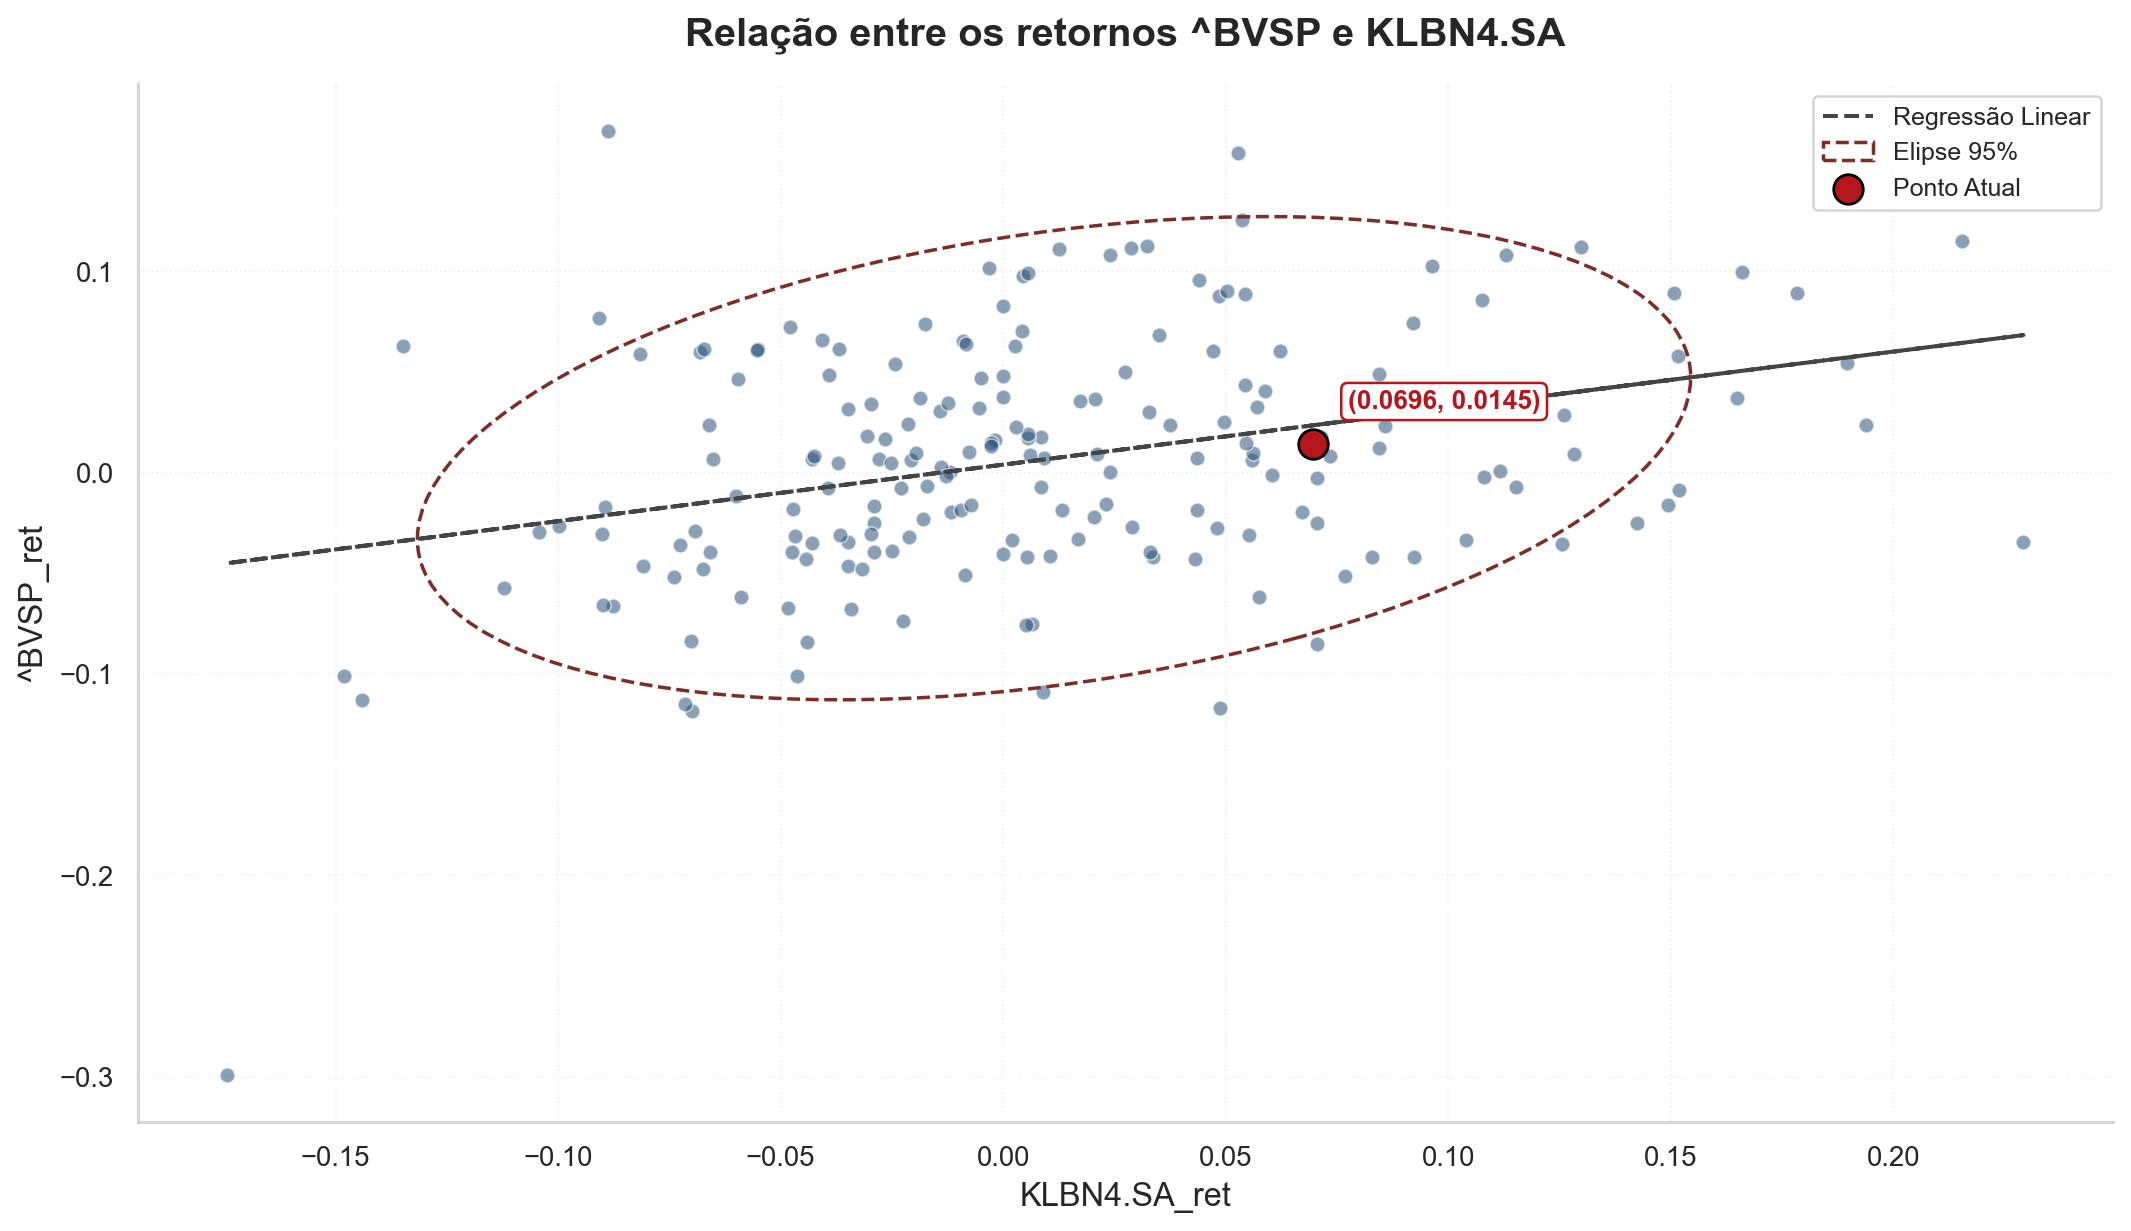

In [134]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 180
plt.figure(figsize=(12, 7))

x = df[f'{ticker_ativo}_ret']
y = df[f'{ticker_indice}_ret']

# --- Gráfico: Dispersão ---
plt.scatter(
    x, y,
    alpha=0.55,
    color="#28527A",          
    edgecolor="white",
    linewidth=0.7
)

# Regressão linear
coef = np.polyfit(x, y, 1)
poly = np.poly1d(coef)

plt.plot(
    x, poly(x),
    color="#444444",
    linestyle="--",
    linewidth=1.6,
    label="Regressão Linear"
)

# Elipse de confiança 95%
cov = np.cov(x, y)
lambda_, v = np.linalg.eig(cov)
lambda_ = np.sqrt(lambda_)

ell = Ellipse(
    xy=(np.mean(x), np.mean(y)),
    width=lambda_[0] * 4,
    height=lambda_[1] * 4,
    angle=np.rad2deg(np.arccos(v[0, 0])),
    edgecolor="#7B2D26",        
    facecolor="none",
    linewidth=1.4,
    linestyle="--",
    label="Elipse 95%"
)
plt.gca().add_patch(ell)

# Ponto atual
ret_ativo_atual = x.iloc[-1]
ret_indice_atual = y.iloc[-1]

plt.scatter(
    ret_ativo_atual, ret_indice_atual,
    color="#B4161B",           
    s=140,
    edgecolor="black",
    linewidth=1.1,
    zorder=5,
    label="Ponto Atual"
)

plt.annotate(
    f"({ret_ativo_atual:.4f}, {ret_indice_atual:.4f})",
    xy=(ret_ativo_atual, ret_indice_atual),
    xytext=(14, 14),
    textcoords="offset points",
    fontsize=10.5,
    weight="bold",
    color="#B4161B",
    bbox=dict(
        boxstyle="round,pad=0.25",
        fc="white", ec="#B4161B", lw=1
    )
)

# Layout e eixos
plt.title(f"Relação entre os retornos {ticker_indice} e {ticker_ativo}", fontsize=16, weight="bold", pad=15)
plt.xlabel(f'{ticker_ativo}_ret', fontsize=13)
plt.ylabel(f'{ticker_indice}_ret', fontsize=13)
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.30)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_alpha(0.80)
ax.spines["bottom"].set_alpha(0.80)

plt.legend(frameon=True, fontsize=10)

plt.tight_layout()
plt.show()